# Tile 与 Arrangement 可视化

本 notebook 使用 NineToothed 的 `visualize` API 展示 tile 和 arrangement 的每一步张量结构变化。

## 核心概念

- **Tensor（张量）**：NineToothed 中的张量不存实际数据，而是存符号表达式（shape、strides 等）
- **tile（分块）**：把一个张量切成大小相同的 block，产生嵌套结构（outer = block 网格，inner = 每个 block）
- **arrangement（编排）**：对所有参数张量做 tile 等操作，使它们的最外层 shape 对齐，编译器据此启动多个 CUDA block

关键规则：
- **每加一次 tile，就增加一层嵌套**（2 层 → 3 层 → ...）
- **expand/squeeze 不增加层级**，只改变 shape
- **编译器只看最外层 shape** 来决定启动多少个 program


In [1]:
import functools
import os
import tempfile

# 设置 matplotlib 无头后端（服务器环境）
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from IPython.display import Image, display

from ninetoothed import Tensor, Symbol
from ninetoothed.visualization import visualize

SAVE_DIR = "/tmp/nb_visuals"
os.makedirs(SAVE_DIR, exist_ok=True)

def show(name):
    path = os.path.join(SAVE_DIR, name)
    return Image(path)

def vis(tensor, name, color=None):
    path = os.path.join(SAVE_DIR, name)
    visualize(tensor, color=color, save_path=path)
    plt.close()


## 1. 基础张量

创建一个 4×8 的二维张量。`visualize` 将其绘制为网格，每个格子代表一个元素。


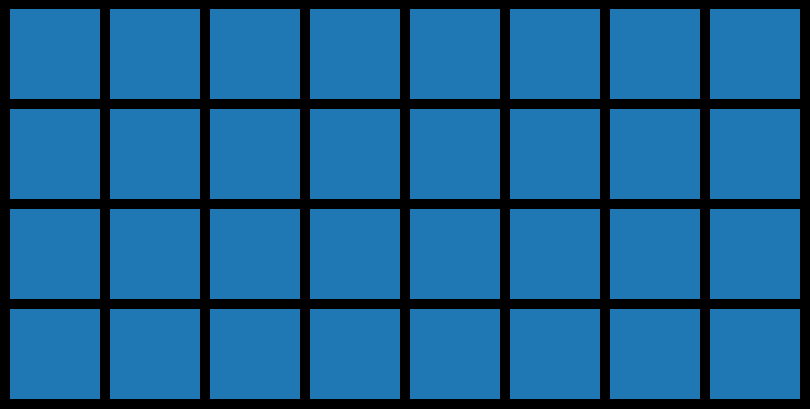

In [2]:
t = Tensor(shape=(4, 8))
vis(t, "01_basic_tensor.png")
display(show("01_basic_tensor.png"))


## 2. 第一次 tile — 2 层结构

`t.tile((2, 2))` 沿两个维度各每 2 个元素切一块，生成 **2 层**结构：

- **外层（Level 0）**：block 网格，shape = (2, 4)
- **内层（Level 1）**：每个 block 是 2×2 的数据

图中每个大方块代表一个 block，内部再分小格子。


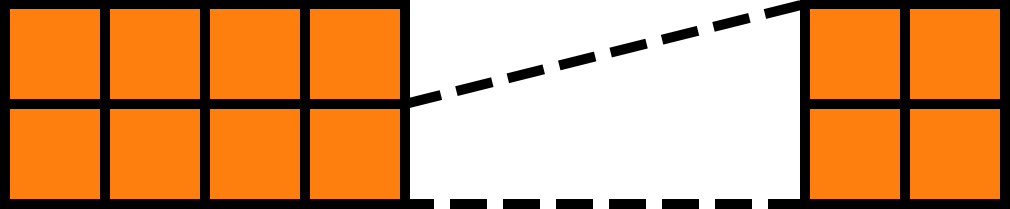

Outer shape (block grid): (2, 4)
Inner shape (each block): (2, 2)


In [3]:
BLOCK_M, BLOCK_N = 2, 2
t_tiled = t.tile((BLOCK_M, BLOCK_N))
vis(t_tiled, "02_tiled_2level.png")
display(show("02_tiled_2level.png"))

print(f"Outer shape (block grid): {t_tiled.shape}")
print(f"Inner shape (each block): {t_tiled.dtype.shape}")


## 3. 第二次 tile — 3 层结构

`t.tile((2, 2)).tile((1, -1))` 再切一次外层，变成 **3 层**：

- **Level 0（最外层）**：super-group 网格 (2, 1)
- **Level 1（中间层）**：一行 3 个 block 的数组 (1, 3)
- **Level 2（最内层）**：2×2 实际数据块

注意：**只有`tile`操作会新增层级**。


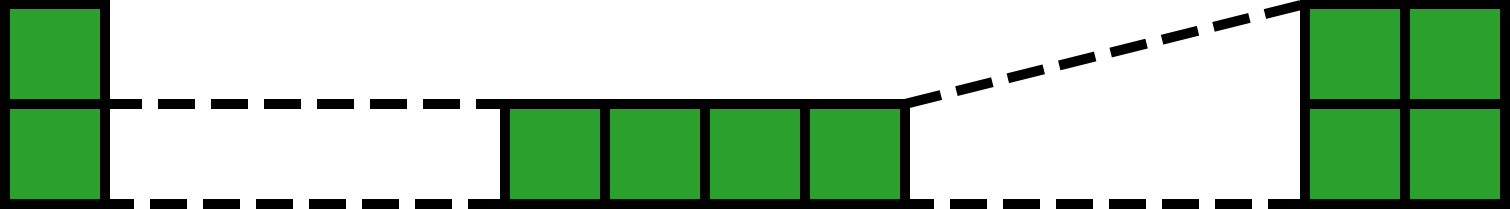

Level 0 shape (super-group): (2, 1)
Level 1 shape (block array): (1, 4)
Level 2 shape (data block):  (2, 2)


In [4]:
t_tiled2 = t.tile((2, 2)).tile((1, -1))
vis(t_tiled2, "03_twotile_3level.png")
display(show("03_twotile_3level.png"))

print(f"Level 0 shape (super-group): {t_tiled2.shape}")
print(f"Level 1 shape (block array): {t_tiled2.dtype.shape}")
print(f"Level 2 shape (data block):  {t_tiled2.dtype.dtype.shape}")


## 4. 向量加法 — 最简单的 arrangement

三个一维向量 x(6), y(6), z(6)，用 BLOCK_SIZE=2 分块。

```python
def arrangement(x, y, z, BLOCK_SIZE=2):
    return x.tile((BLOCK_SIZE,)), y.tile((BLOCK_SIZE,)), z.tile((BLOCK_SIZE,))
```

每个 tensor 只做一次 tile，都是 2 层，outer shape 自动对齐为 (3,)。编译器启动 3 个 program。


x outer shape: (3,), inner: (2,)
y outer shape: (3,), inner: (2,)
z outer shape: (3,), inner: (2,)
All outer shapes match → compiler launches 3 programs


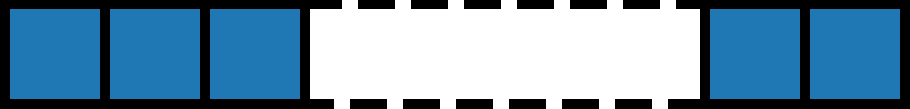

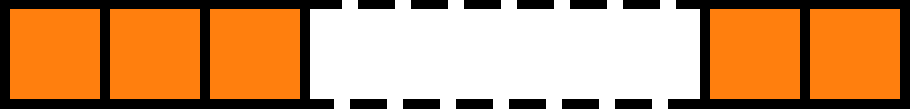

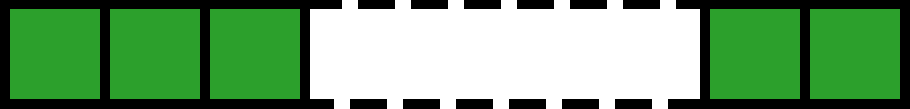

In [5]:
x = Tensor(shape=(6,))
y = Tensor(shape=(6,))
z = Tensor(shape=(6,))

BLOCK_SIZE = 2

x_tiled = x.tile((BLOCK_SIZE,))
y_tiled = y.tile((BLOCK_SIZE,))
z_tiled = z.tile((BLOCK_SIZE,))

print(f"x outer shape: {x_tiled.shape}, inner: {x_tiled.dtype.shape}")
print(f"y outer shape: {y_tiled.shape}, inner: {y_tiled.dtype.shape}")
print(f"z outer shape: {z_tiled.shape}, inner: {z_tiled.dtype.shape}")
print(f"All outer shapes match → compiler launches {x_tiled.shape[0]} programs")

vis(x_tiled, "04_vecadd_x.png", color="C0")
vis(y_tiled, "04_vecadd_y.png", color="C1")
vis(z_tiled, "04_vecadd_z.png", color="C2")

display(show("04_vecadd_x.png"))
display(show("04_vecadd_y.png"))
display(show("04_vecadd_z.png"))


## 5. 矩阵乘法 arrangement — 步骤拆解

矩阵乘法 C = A × B，其中 A(4×6), B(6×8), C(4×8)。BLOCK_SIZE = 2。

### 5.1 原始张量


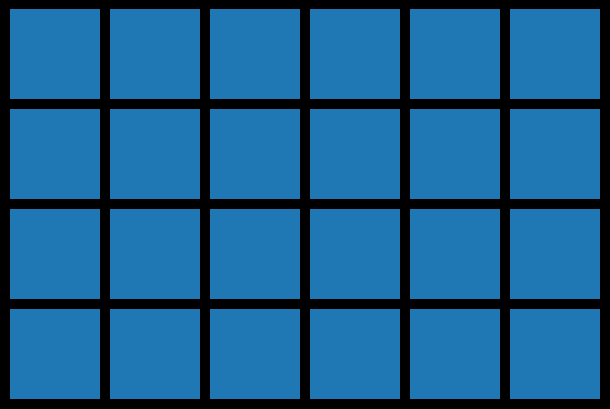

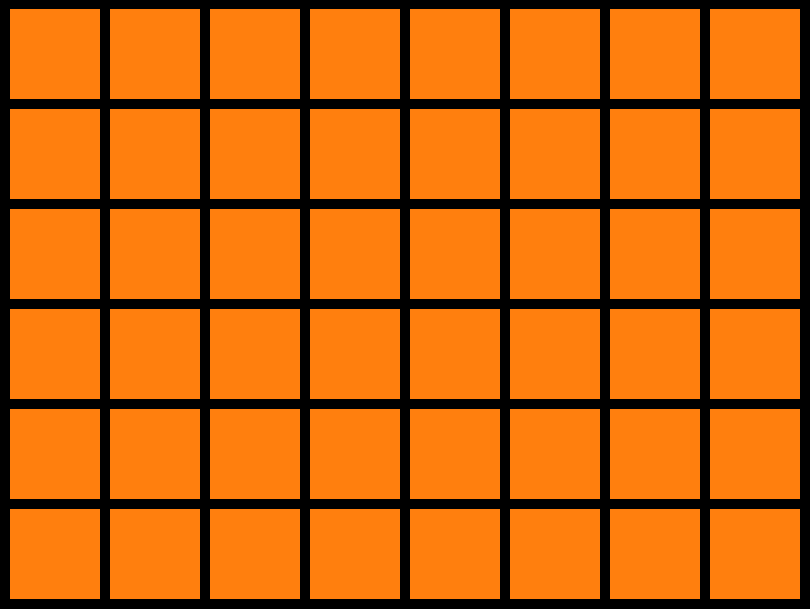

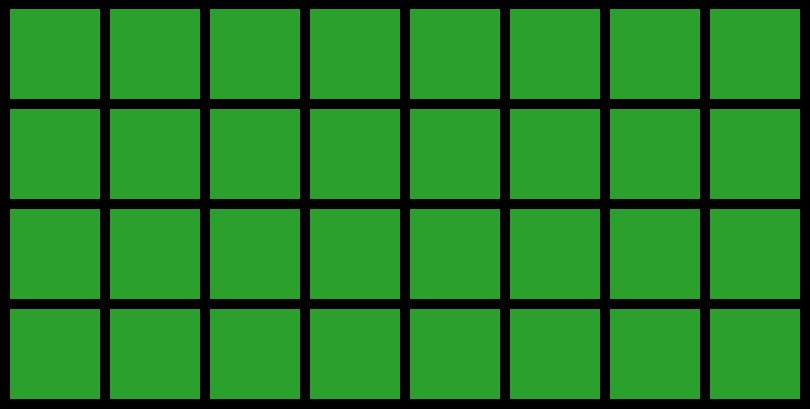

In [6]:
M, K, N = 4, 6, 8
BLOCK = 2

A = Tensor(shape=(M, K))
B = Tensor(shape=(K, N))
C = Tensor(shape=(M, N))

vis(A, "05_matmul_A_raw.png", color="C0")
vis(B, "05_matmul_B_raw.png", color="C1")
vis(C, "05_matmul_C_raw.png", color="C2")

display(show("05_matmul_A_raw.png"))
display(show("05_matmul_B_raw.png"))
display(show("05_matmul_C_raw.png"))


### 5.2 第一次 tile — 每个张量切成 block

```python
A.tile((2, 2))  → outer (2, 3), inner (2, 2)
B.tile((2, 2))  → outer (3, 4), inner (2, 2)
C.tile((2, 2))  → outer (2, 4), inner (2, 2)
```

**问题**：outer shape 不匹配！A(2,3) ≠ B(3,4) ≠ C(2,4)。编译器不知道如何配对。


A: outer (2, 3), inner (2, 2)
B: outer (3, 4), inner (2, 2)
C: outer (2, 4), inner (2, 2)

Outer shapes DIFFER! Compiler can't align them.


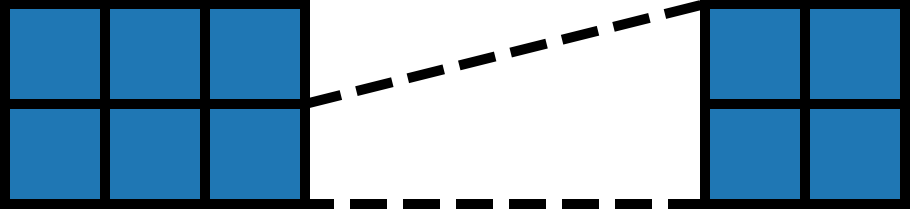

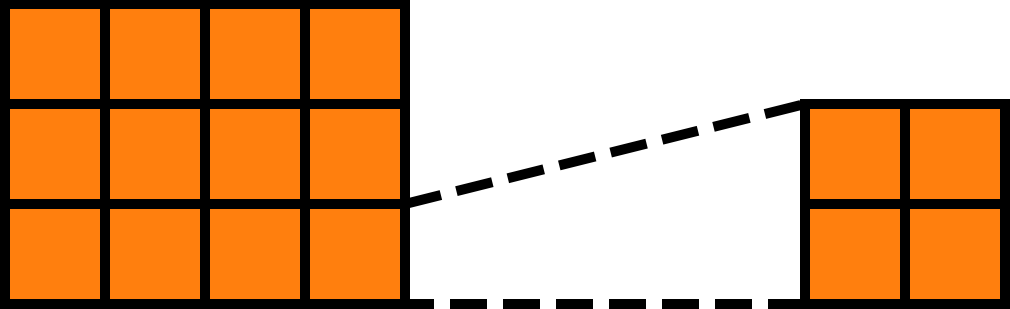

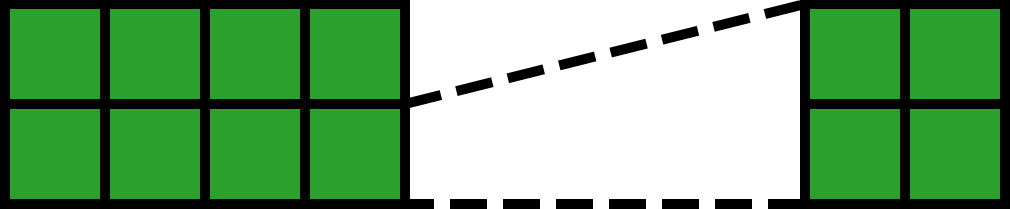

In [7]:
A_t1 = A.tile((BLOCK, BLOCK))
B_t1 = B.tile((BLOCK, BLOCK))
C_t1 = C.tile((BLOCK, BLOCK))

print(f"A: outer {A_t1.shape}, inner {A_t1.dtype.shape}")
print(f"B: outer {B_t1.shape}, inner {B_t1.dtype.shape}")
print(f"C: outer {C_t1.shape}, inner {C_t1.dtype.shape}")
print()
print("Outer shapes DIFFER! Compiler can't align them.")

vis(A_t1, "06_matmul_A_tile1.png", color="C0")
vis(B_t1, "06_matmul_B_tile1.png", color="C1")
vis(C_t1, "06_matmul_C_tile1.png", color="C2")

display(show("06_matmul_A_tile1.png"))
display(show("06_matmul_B_tile1.png"))
display(show("06_matmul_C_tile1.png"))


### 5.3 第二次 tile — A 按行分组，B 按列分组 → 3 层

```python
A.tile((2,2)).tile((1, -1))  → outer (2,1), dtype (1,3), dtype₂ (2,2)
B.tile((2,2)).tile((-1, 1))  → outer (1,4), dtype (3,1), dtype₂ (2,2)
C.tile((2,2))                → outer (2,4), dtype (2,2)         ← 不变
```

- `tile((1, -1))`：dim 0 每 1 行一组 → 2 个 super-group；dim 1 -1 = 全部 → 1 个 super-group
- `tile((-1, 1))`：dim 0 -1 = 全部 → 1 个 super-group；dim 1 每 1 列一组 → 4 个 super-group


A: super-group outer (2, 1)
   level-1 (block array) (1, 3)
   level-2 (data block)  (2, 2)

B: super-group outer (1, 4)
   level-1 (block array) (3, 1)
   level-2 (data block)  (2, 2)


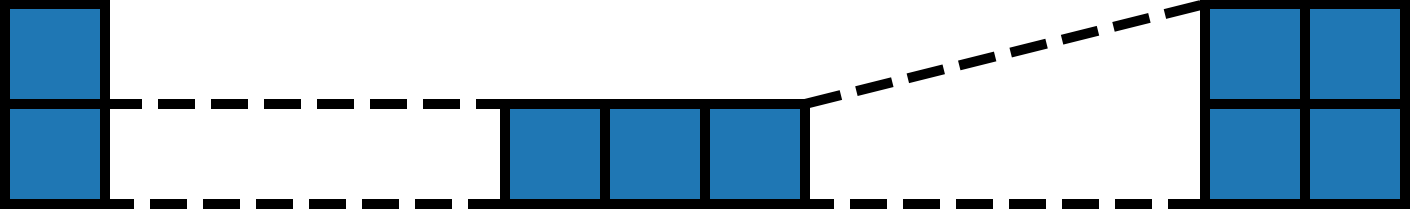

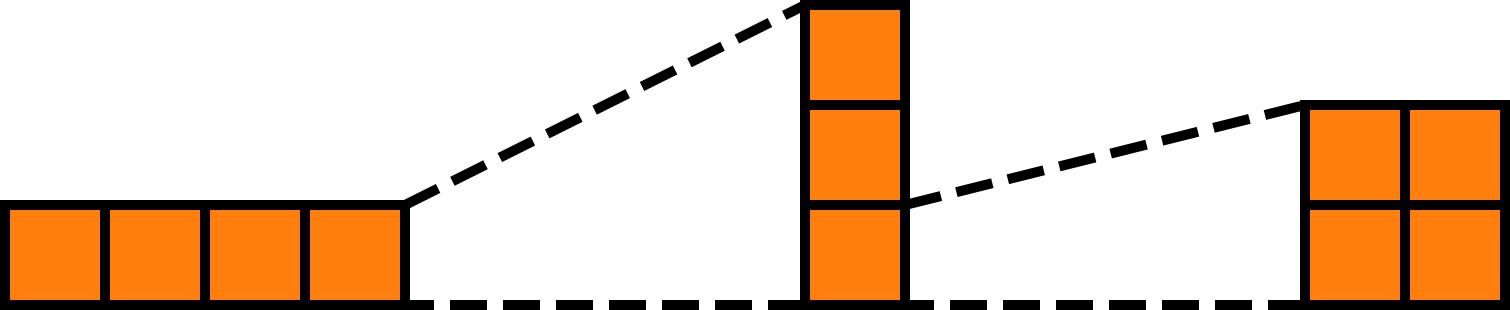

In [8]:
# A: group rows
A_t2 = A.tile((BLOCK, BLOCK)).tile((1, -1))
print(f"A: super-group outer {A_t2.shape}")
print(f"   level-1 (block array) {A_t2.dtype.shape}")
print(f"   level-2 (data block)  {A_t2.dtype.dtype.shape}")
print()

# B: group cols
B_t2 = B.tile((BLOCK, BLOCK)).tile((-1, 1))
print(f"B: super-group outer {B_t2.shape}")
print(f"   level-1 (block array) {B_t2.dtype.shape}")
print(f"   level-2 (data block)  {B_t2.dtype.dtype.shape}")

vis(A_t2, "07_matmul_A_tile2.png", color="C0")
vis(B_t2, "07_matmul_B_tile2.png", color="C1")

display(show("07_matmul_A_tile2.png"))
display(show("07_matmul_B_tile2.png"))


### 5.4 Expand — 对齐 outer shape

当前 outer shapes：A(2,1), B(1,4), C(2,4)。仍不匹配！

```python
# A: dim 1 从 1 扩到 4 (复制到每个 C 的 column block)
A.tile(...).expand((-1, C_t1.shape[1]))
# B: dim 0 从 1 扩到 2 (复制到每个 C 的 row block)
B.tile(...).expand((C_t1.shape[0], -1))
```

`expand` 不新增层级，只把 size-1 维度复制多份。所有 program 共享同一份数据（零成本广播）。


A after expand: outer (2, 4)
B after expand: outer (2, 4)
C:              outer (2, 4)

All outer shapes MATCH → compiler launches 2×4 = 8 programs


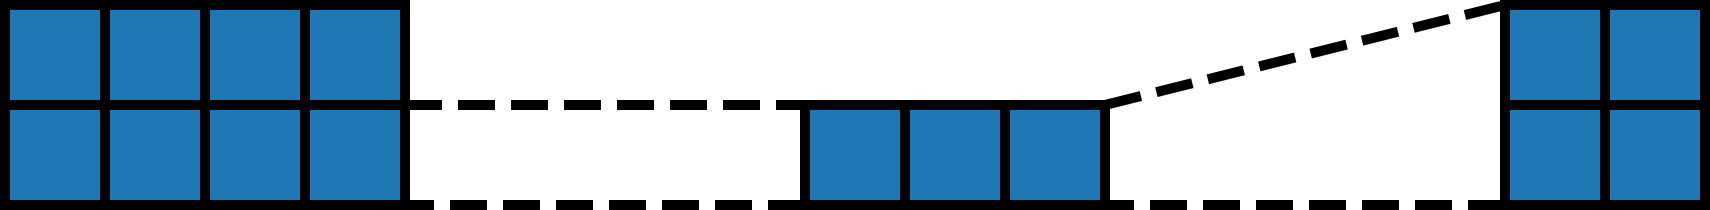

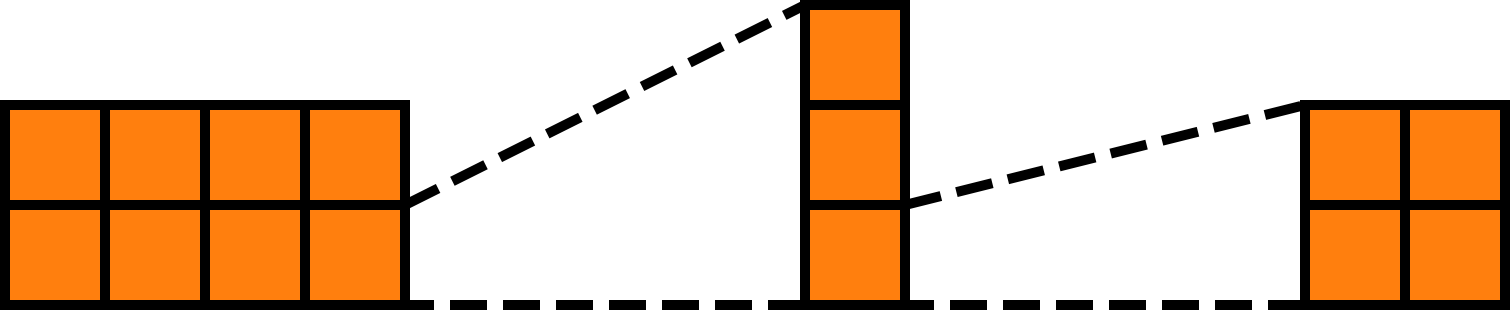

In [9]:
C_outer_shape = C_t1.shape  # (2, 4)

# A: expand dim 1
A_t3 = A_t2.expand((-1, C_outer_shape[1]))
print(f"A after expand: outer {A_t3.shape}")

# B: expand dim 0
B_t3 = B_t2.expand((C_outer_shape[0], -1))
print(f"B after expand: outer {B_t3.shape}")
print(f"C:              outer {C_t1.shape}")
print()
print(f"All outer shapes MATCH → compiler launches {C_outer_shape[0]}×{C_outer_shape[1]} = {C_outer_shape[0]*C_outer_shape[1]} programs")

vis(A_t3, "08_matmul_A_expand.png", color="C0")
vis(B_t3, "08_matmul_B_expand.png", color="C1")

display(show("08_matmul_A_expand.png"))
display(show("08_matmul_B_expand.png"))


### 5.5 Squeeze — 简化中间层

```python
# dtype shape (1, 3) → squeeze(0) → (3,)
# dtype shape (3, 1) → squeeze(1) → (3,)
A_t4 = A_t3; A_t4.dtype = A_t4.dtype.squeeze(0)
B_t4 = B_t3; B_t4.dtype = B_t4.dtype.squeeze(1)
```

去除 size-1 维度后，application 函数的参数形状从 (1,3) 变为 (3,)，可以用 `input[k]` 直接索引。


A final: outer (2, 4), level-1 (after squeeze) (3,)
B final: outer (2, 4), level-1 (after squeeze) (3,)
C final: outer (2, 4), level-1 (2, 2)

Application function receives level-1 tensors:
  def application(input, other, output):
    # input.shape = (3,)  ← 3 blocks, each (2,2)
    # other.shape = (3,)  ← 3 blocks, each (2,2)
    # output.shape = (2,2)
    for k in range(input.shape[0]):
      accumulator += dot(input[k], other[k])


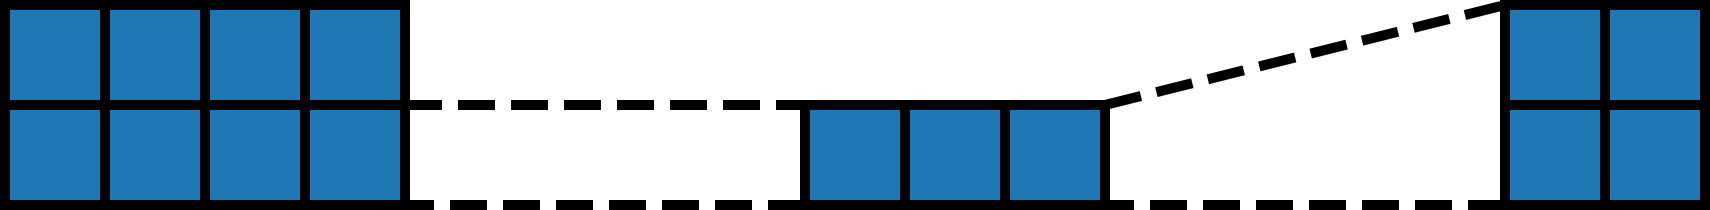

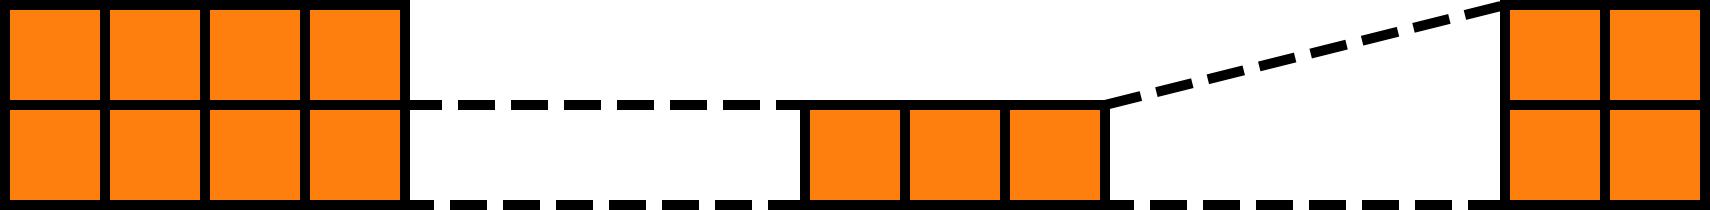

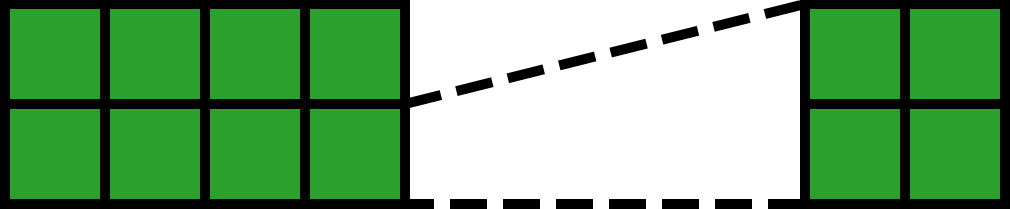

In [10]:
A_t4 = A_t3  # same outer
A_t4.dtype = A_t4.dtype.squeeze(0)
B_t4 = B_t3
B_t4.dtype = B_t4.dtype.squeeze(1)

print(f"A final: outer {A_t4.shape}, level-1 (after squeeze) {A_t4.dtype.shape}")
print(f"B final: outer {B_t4.shape}, level-1 (after squeeze) {B_t4.dtype.shape}")
print(f"C final: outer {C_t1.shape}, level-1 {C_t1.dtype.shape}")
print()
print("Application function receives level-1 tensors:")
print("  def application(input, other, output):")
print("    # input.shape = (3,)  ← 3 blocks, each (2,2)")
print("    # other.shape = (3,)  ← 3 blocks, each (2,2)")
print("    # output.shape = (2,2)")
print("    for k in range(input.shape[0]):")
print("      accumulator += dot(input[k], other[k])")

vis(A_t4, "09_matmul_A_final.png", color="C0")
vis(B_t4, "09_matmul_B_final.png", color="C1")
vis(C_t1, "09_matmul_C_final.png", color="C2")

display(show("09_matmul_A_final.png"))
display(show("09_matmul_B_final.png"))
display(show("09_matmul_C_final.png"))


## 6. 完整 arrangement 函数

最终，矩阵乘法的 arrangement 函数如下。整个过程就是"切块 → 再切 → 对齐 → 简化"。


In [11]:
def arrangement(input, other, output):
    BLOCK_M = BLOCK_N = BLOCK_K = BLOCK

    output_arranged = output.tile((BLOCK_M, BLOCK_N))

    input_arranged = input.tile((BLOCK_M, BLOCK_K))
    input_arranged = input_arranged.tile((1, -1))
    input_arranged = input_arranged.expand((-1, output_arranged.shape[1]))
    input_arranged.dtype = input_arranged.dtype.squeeze(0)

    other_arranged = other.tile((BLOCK_K, BLOCK_N))
    other_arranged = other_arranged.tile((-1, 1))
    other_arranged = other_arranged.expand((output_arranged.shape[0], -1))
    other_arranged.dtype = other_arranged.dtype.squeeze(1)

    return input_arranged, other_arranged, output_arranged

result = arrangement(Tensor(shape=(M, K)), Tensor(shape=(K, N)), Tensor(shape=(M, N)))
names = ["input (A)", "other (B)", "output (C)"]
for name, tensor in zip(names, result):
    print(f"{name}: outer {tensor.shape}, level-1 {tensor.dtype.shape}")


input (A): outer (2, 4), level-1 (3,)
other (B): outer (2, 4), level-1 (3,)
output (C): outer (2, 4), level-1 (2, 2)


## 7. 使用不同颜色可视化各个张量

可以用 `color` 参数为不同张量指定颜色，便于区分。


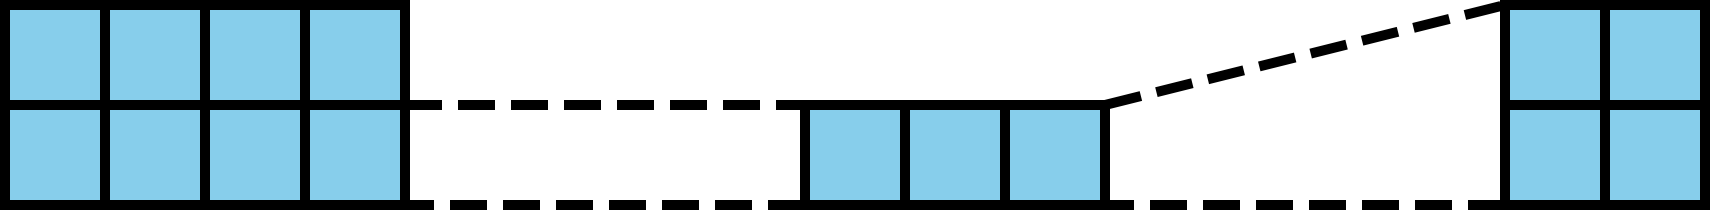

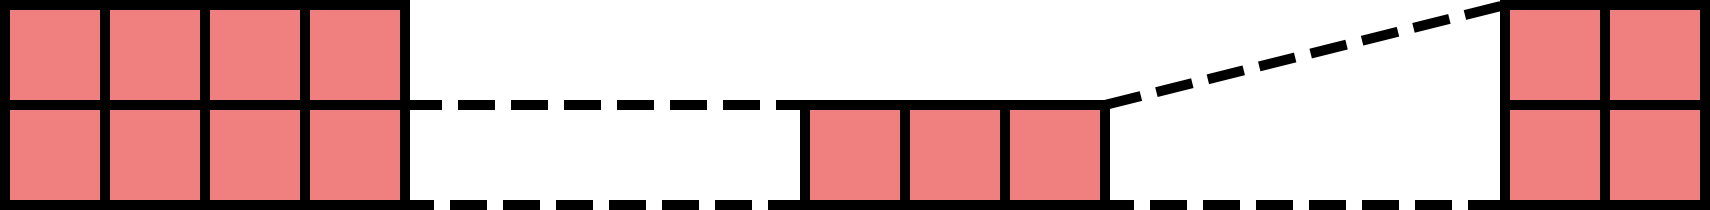

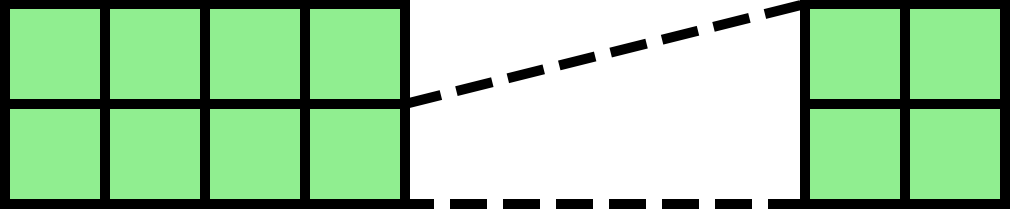

In [12]:
# 把三个 final tensor 用不同颜色并列展示
vis(A_t4, "10_final_A_color.png", color="skyblue")
vis(B_t4, "10_final_B_color.png", color="lightcoral")
vis(C_t1, "10_final_C_color.png", color="lightgreen")

display(show("10_final_A_color.png"))
display(show("10_final_B_color.png"))
display(show("10_final_C_color.png"))


## 总结

| 操作 | 增层级？ | 作用 |
|---|---|---|
| `tile(size)` | **是** | 将当前层切块，新增一层 outer，原层变为 inner |
| `expand(shape)` | 否 | size-1 维度广播复制，对齐 outer shape |
| `squeeze(dim)` | 否 | 去掉中间层的 size-1 维度，简化索引 |

### Arrangement 三步法

1. **tile → tile**：对每个张量切块，产生多层结构（外层对齐用，中层迭代用，内层数据用）
2. **expand**：把外层 shape 强行对齐到目标（通常是输出张量的 outer shape）
3. **squeeze**：去掉中间层多余的 size-1 维度

编译器只看最外层 shape → 启动 N 个 CUDA block → 每个 block 拿到中间层数据 → 内层是实际计算的 tile。
